In [1]:
import torch
import torch.nn as nn
from torch.optim import SGD
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import numpy as np
import matplotlib.pyplot as plt

# Data Base

In [2]:
def npy_loader(path):
    return torch.from_numpy(np.load(path))

In [3]:
ThinTrainDataImages = npy_loader("DataBase2\\ThinDataBase\\ThinTrainDataImages.npy")
ThinTrainDataLables = npy_loader("DataBase2\\ThinDataBase\\ThinTrainDataLables.npy")
ThinTestDataImages = npy_loader("DataBase2\\ThinDataBase\\ThinTestDataImages.npy")
ThinTestDataLables = npy_loader("DataBase2\\ThinDataBase\\ThinTestDataLables.npy")

### Labels

 - 0 = SetaBaixo;
 - 1 = SetaCima;
 - 2 = SetaEsquerda;
 - 3 = SetaDireita;
 - 4 = Circulo;
 - 5 = Coroa.

## Dataset Object

In [4]:
def npy_loader(path):
    return torch.from_numpy(np.load(path))

class CTDataset(Dataset):
    def __init__(self, filepathImg, filepathLables):
        self.x = npy_loader(filepathImg).to(torch.float32)
        self.y = npy_loader(filepathLables)
        self.x = self.x / 255.
        self.y = torch.tensor(self.y, dtype=torch.long)
    def __len__(self): 
        return self.x.shape[0]
    def __getitem__(self, ix): 
        return self.x[ix], self.y[ix]

In [5]:
ThinTrain_ds = CTDataset("DataBase2\\ThinDataBase\\ThinTrainDataImages.npy","DataBase2\\ThinDataBase\\ThinTrainDataLables.npy")
ThinTest_ds = CTDataset("DataBase2\\ThinDataBase\\ThinTestDataImages.npy","DataBase2\\ThinDataBase\\ThinTestDataLables.npy")

C:\Users\R2\AppData\Local\Temp\ipykernel_8600\3204536404.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.y = torch.tensor(self.y, dtype=torch.long)


## Data Loader

In [6]:
ThinTrain_dl = DataLoader(ThinTrain_ds,batch_size=5)
for x, y in ThinTrain_dl:
    print(x.shape)
    print(x.dtype)
    print(y.shape)
    print(y.dtype)
    break

torch.Size([5, 28, 28])
torch.float32
torch.Size([5])
torch.int64


### Cross Entropy Loss (Função calculo de erro)

In [7]:
L = nn.CrossEntropyLoss()

# A Rede

In [8]:
class MyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,6,3,padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(6,18,3)
        self.fc1 = nn.Linear(18*6*6,100)
        self.fc2 = nn.Linear(100,50)
        self.fc3 = nn.Linear(50,6)
        self.R = nn.ReLU()
    def forward(self,x):
        x = self.pool(self.R(self.conv1(x)))
        x = self.pool(self.R(self.conv2(x)))
        x = x.view(-1,18*6*6)
        x = self.R(self.fc1(x))
        x = self.R(self.fc2(x))
        x = self.fc3(x)
        return x.squeeze()

In [9]:
f = MyCNN()

## Treinamento

In [10]:
def train_model(dl, f, n_epochs=20):
    # Optimization
    opt = SGD(f.parameters(), lr=0.01)
    L = nn.CrossEntropyLoss()

    # Train model
    losses = []
    epochs = []
    for epoch in range(n_epochs):
        print(f'Epoch {epoch}')
        N = len(dl)
        running_loss = 0
        for i, (x, y) in enumerate(dl):
            # Update the weights of the network
            opt.zero_grad() 
            loss_value = L(f(x.view(len(y),1,28,28)), y) 
            loss_value.backward() 
            opt.step() 
            # Store training data
            epochs.append(epoch+i/N)
            losses.append(loss_value.item())
            running_loss += loss_value.item()
        print(f'Loss: {running_loss / N:.4f}')
    return np.array(epochs), np.array(losses)

In [11]:
epoch_data, loss_data = train_model(ThinTrain_dl,f,n_epochs=10)

Epoch 0
Loss: 1.4303
Epoch 1
Loss: 0.0215
Epoch 2
Loss: 0.0119
Epoch 3
Loss: 0.0083
Epoch 4
Loss: 0.0064
Epoch 5
Loss: 0.0053
Epoch 6
Loss: 0.0046
Epoch 7
Loss: 0.0039
Epoch 8
Loss: 0.0034
Epoch 9
Loss: 0.0031


Text(0.5, 1.0, 'Cross Entropy (per batch)')

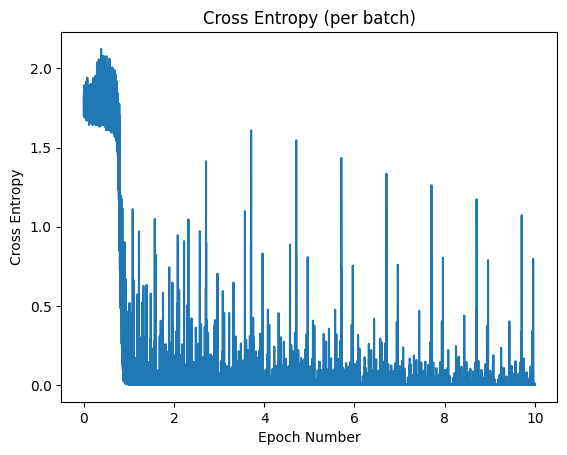

In [12]:
plt.plot(epoch_data, loss_data)
plt.xlabel('Epoch Number')
plt.ylabel('Cross Entropy')
plt.title('Cross Entropy (per batch)')

In [14]:
epoch_data_avgd = epoch_data.reshape(10,-1).mean(axis=1)
loss_data_avgd = loss_data.reshape(10,-1).mean(axis=1)

Text(0.5, 1.0, 'Cross Entropy (avgd per epoch)')

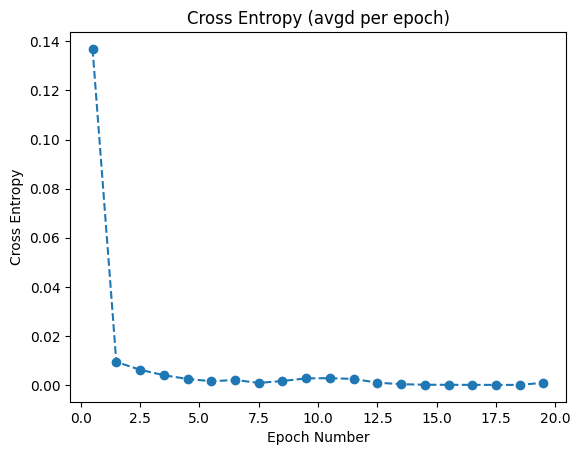

In [ ]:
plt.plot(epoch_data_avgd, loss_data_avgd, 'o--')
plt.xlabel('Epoch Number')
plt.ylabel('Cross Entropy')
plt.title('Cross Entropy (avgd per epoch)')

In [15]:
xs, ys = ThinTest_ds[0:100]
yhats = np.zeros(shape=(100))
i=0
for each in xs:
    yhats[i] = f(each.view(1,28,28)).argmax().item()
    i += 1


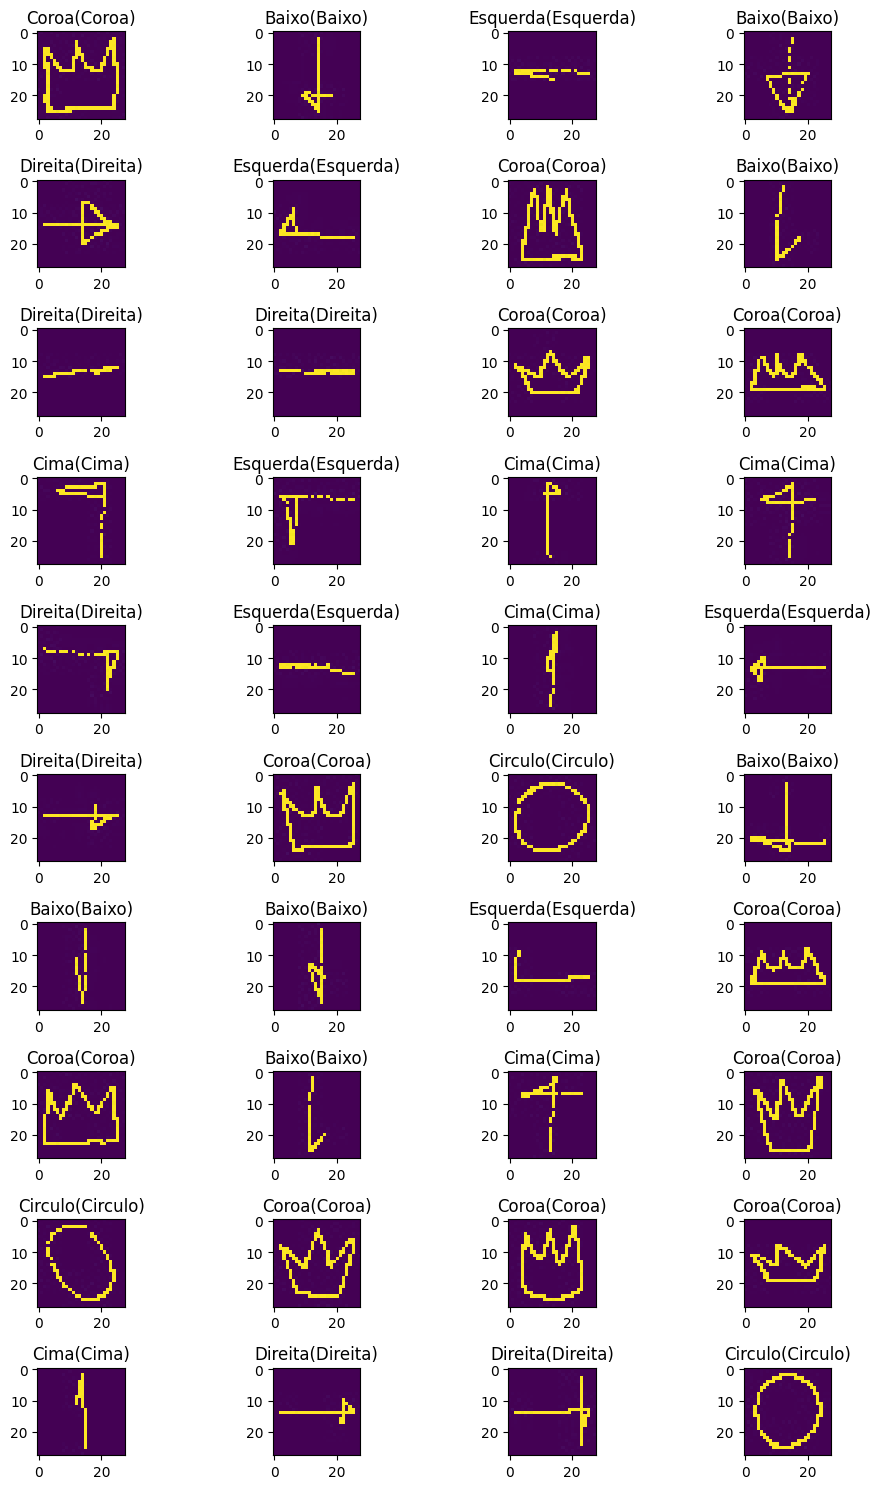

In [16]:
fig, ax = plt.subplots(10,4,figsize=(10,15))
for i in range(40):
    plt.subplot(10,4,i+1)
    plt.imshow(xs[i])
    match yhats[i]:
        case 0:
            name = "Baixo"
        case 1:
            name = "Cima"
        case 2:
            name = "Esquerda"
        case 3:
            name = "Direita"
        case 4:
            name = "Circulo"
        case 5:
            name = "Coroa"
    match ys[i]:
        case 0:
            Rname = "Baixo"
        case 1:
            Rname = "Cima"
        case 2:
            Rname = "Esquerda"
        case 3:
            Rname = "Direita"
        case 4:
            Rname = "Circulo"
        case 5:
            Rname = "Coroa"
    plt.title(f'{name}({Rname})')
fig.tight_layout()
plt.show()

In [17]:
print(f)

MyCNN(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 18, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=648, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=50, bias=True)
  (fc3): Linear(in_features=50, out_features=6, bias=True)
  (R): ReLU()
)


In [18]:
torch.save(f.state_dict(), 'CNN5.pth')

In [19]:
import torch
ThinTestImages = ThinTest_ds.x
ThinTestLables = ThinTest_ds.y
print(ThinTestImages.shape,ThinTestLables.shape)

acertos = 0
total = 5235
yResposta = np.zeros(shape=(5235))

with torch.no_grad():
    for i in range(5235):
        yResposta[i] = f(ThinTestImages[i].view(1,28,28)).argmax().item()
        if yResposta[i] == ThinTestLables[i]:
            acertos += 1
        i += 1

precisao = (acertos/total)*100
print(f'Precisão da rede = {precisao}')

torch.Size([5235, 28, 28]) torch.Size([5235])
Precisão da rede = 99.86628462273161
